<a href="https://colab.research.google.com/github/Samu24042/CienciaDeDatos/blob/main/ProyectoFInal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import shapiro
from scipy import stats
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats



In [26]:
df = pd.read_csv('3min_resting.csv',sep = ';', skiprows=1)
df.sample(n=5)

,Fatigue,S1_MeanRR,S1_SDNN,S1_MinHR,S1_MaxHR,S1_RMSSD,S1_pNNxx,S1_HRVtriangularindex,S1_VLFpow_FFT_log,S1_LFpow_FFT_log,...,S1_TOTpow_FFT,S1_LF_HF_ratio_FFT,S1_SD1,S1_SD2,S1_SD2_SD1_ratio,S1_ApEn,S1_SampEn,S1_D2,S1_DFA1,S1_DFA2
124,1,882.685343,55.965620,60.036983,77.847062,53.918614,34.482759,11.333333,5.065810,7.164431,...,7.617512,2.222069,38.220718,69.121211,1.808475,0.927499,1.863376,4.338214,1.202971,0.206815
152,1,899.945032,74.575321,57.173241,89.648845,79.023928,54.822335,18.000000,6.772631,7.924843,...,8.685843,1.222605,56.021463,89.529708,1.598132,0.798317,1.662596,2.120927,0.905312,0.552656
67,0,764.164596,48.863957,65.757460,90.445353,44.915515,30.341880,10.217391,5.331794,7.090388,...,7.827109,1.091072,31.829147,61.356165,1.927672,0.992870,1.961677,4.107440,1.029389,0.447685
34,0,623.866574,31.421687,86.633092,109.822929,18.490545,1.041667,9.322581,4.796350,6.655293,...,6.965617,4.815415,13.097801,42.521316,3.246447,1.096425,1.498795,1.203369,1.530881,0.492119
99,1,759.296624,57.590851,64.712772,96.410013,41.816441,21.186441,11.285714,5.396922,6.975880,...,7.656227,1.304680,29.631535,76.032034,2.565916,0.990922,1.641996,3.650520,1.395439,0.511943


In [27]:
# --- INSPECCIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS ---

# isna().sum() nos muestra cuántos valores faltantes hay por cada columna
print("--- Valores nulos por columna ---")
print(df.isna().sum())

--- Valores nulos por columna ---
Fatigue                  0
S1_MeanRR                0
S1_SDNN                  0
S1_MinHR                 0
S1_MaxHR                 0
S1_RMSSD                 0
S1_pNNxx                 0
S1_HRVtriangularindex    0
S1_VLFpow_FFT_log        0
S1_LFpow_FFT_log         0
S1_HFpow_FFT_log         0
S1_TOTpow_FFT            0
S1_LF_HF_ratio_FFT       0
S1_SD1                   0
S1_SD2                   0
S1_SD2_SD1_ratio         0
S1_ApEn                  0
S1_SampEn                0
S1_D2                    0
S1_DFA1                  0
S1_DFA2                  0
dtype: int64


In [28]:
# 1. Separamos la etiqueta 'Fatigue' (y) de las variables del corazón (X)
X = df.drop(columns=['Fatigue'])
features = X.columns.tolist()
y = df['Fatigue']

# 2. Inicializamos el estandarizador (StandardScaler)
scaler = StandardScaler()

# 3. Ajustamos y transformamos la matriz X
X_scaled = scaler.fit_transform(X)

print("--- REPORTE DE ESTANDARIZACIÓN ---")
print(f"-> Matriz original X: {X.shape[0]} filas y {X.shape[1]} columnas.")
print(f"-> Matriz X_escalado lista: {X_scaled.shape[0]} filas y {X_scaled.shape[1]} variables transformadas.")
print(f"-> Vector y (etiquetas): {y.shape[0]} filas.")

--- REPORTE DE ESTANDARIZACIÓN ---
-> Matriz original X: 164 filas y 20 columnas.
-> Matriz X_escalado lista: 164 filas y 20 variables transformadas.
-> Vector y (etiquetas): 164 filas.


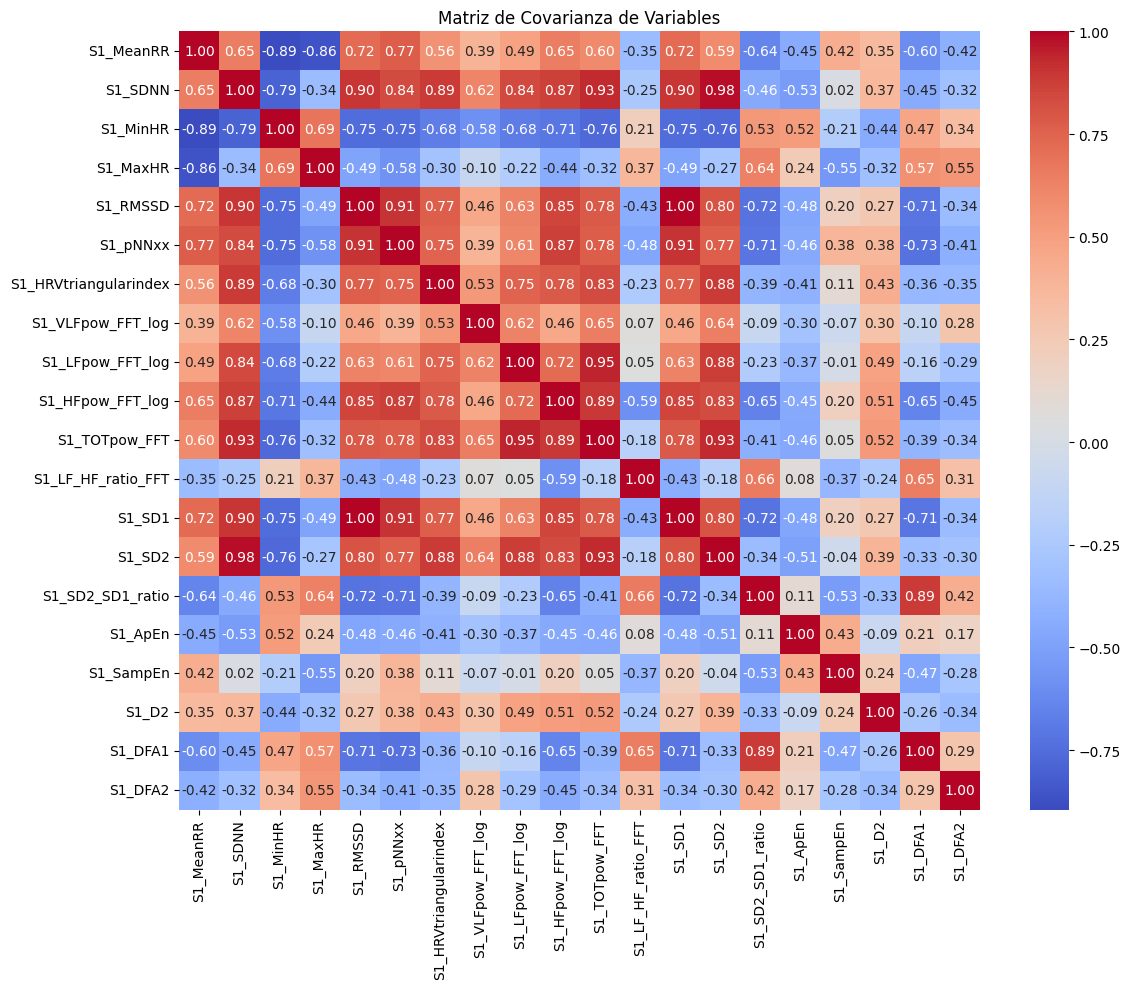

In [29]:
# =====================================================================
# 2. Calcular la matriz de covarianza y graficar mapa de calor
# =====================================================================
# Calcular la matriz de covarianza sobre los datos estandarizados
cov_matrix = np.cov(X_scaled, rowvar=False, ddof=0)
# print("Matriz de correlación:",cov_matrix)

# Graficar la matriz de covarianza utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=features, yticklabels=features)
plt.title('Matriz de Covarianza de Variables')
plt.tight_layout()
plt.show()

In [30]:
# =====================================================================
# PASO 3: CÁLCULO DEL PCA (REDUCCIÓN A 3 COMPONENTES)
# =====================================================================
# 1. Inicializamos el PCA para 3 componentes
pca = PCA(n_components=3, random_state=42)

# 2. Ajustamos y transformamos la matriz de datos escalados
X_pca = pca.fit_transform(X_scaled) # Asegúrate de que se llame igual a tu variable escalada

# 3. Creamos el nuevo DataFrame con los componentes y la etiqueta de Fatiga
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Fatigue'] = y.values

# 4. Mostramos el reporte de varianza explicada
varianza_explicada = pca.explained_variance_ratio_
print("--- REPORTE DE VARIANZA EXPLICADA POR EL PCA ---")
print(f"Componente Principal 1 (PC1): {varianza_explicada[0]*100:.2f}% de la información.")
print(f"Componente Principal 2 (PC2): {varianza_explicada[1]*100:.2f}% de la información.")
print(f"Componente Principal 3 (PC3): {varianza_explicada[2]*100:.2f}% de la información.")
print(f"TOTAL DE INFORMACIÓN RETENIDA: {sum(varianza_explicada)*100:.2f}%\n")

print("Muestra aleatoria del nuevo dataset reducido:")
df_pca.sample(n=5, random_state=42)

--- REPORTE DE VARIANZA EXPLICADA POR EL PCA ---
Componente Principal 1 (PC1): 55.78% de la información.
Componente Principal 2 (PC2): 15.52% de la información.
Componente Principal 3 (PC3): 6.55% de la información.
TOTAL DE INFORMACIÓN RETENIDA: 77.86%

Muestra aleatoria del nuevo dataset reducido:


,PC1,PC2,PC3,Fatigue
135,4.568060,-1.484050,0.453066,1
115,-0.902485,0.667214,-0.051636,1
131,2.567540,-2.630345,-0.789504,1
55,-5.912010,0.064088,-0.534605,0
95,-2.428856,0.933850,-2.230974,1


In [31]:
# =====================================================================
# PASO 4: GRAFICACIÓN INTERACTIVA EN 3D
# =====================================================================

# 1. Entrenamos rápidamente la Regresión Logística para extraer los coeficientes del hiperplano
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(df_pca[['PC1', 'PC2', 'PC3']], df_pca['Fatigue'])

coefs = modelo_lr.coef_[0]
intercepto = modelo_lr.intercept_[0]

# 2. Definimos los límites del plano ajustados ESTRICTAMENTE al rango de tus puntos reales
# Esto evita que Plotly aleje la cámara (zoom out) y aplane la gráfica visualmente
x_min, x_max = df_pca['PC1'].min(), df_pca['PC1'].max()
y_min, y_max = df_pca['PC2'].min(), df_pca['PC2'].max()

x_range = np.linspace(x_min, x_max, 20)
y_range = np.linspace(y_min, y_max, 20)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# 3. Despejamos matemáticamente Z (PC3) de la ecuación del hiperplano:
# beta_0 + beta_1*PC1 + beta_2*PC2 + beta_3*PC3 = 0  ->  PC3 = -(beta_1*PC1 + beta_2*PC2 + beta_0) / beta_3
Z_mesh = -(coefs[0] * X_mesh + coefs[1] * Y_mesh + intercepto) / coefs[2]

# 4. CONSTRUIMOS LA FIGURA UTILIZANDO GRAPH OBJECTS (Para combinar puntos y superficies)
fig = go.Figure()

# Trazado 1: Puntos de estudiantes NO Fatigados (Mismos colores discretos de tu px.scatter_3d)
fig.add_trace(go.Scatter3d(
    x=df_pca[df_pca['Fatigue'] == 0]['PC1'],
    y=df_pca[df_pca['Fatigue'] == 0]['PC2'],
    z=df_pca[df_pca['Fatigue'] == 0]['PC3'],
    mode='markers',
    name='No Fatigado (Baseline)',
    marker=dict(size=5, color='royalblue', opacity=0.8)
))

# Trazado 2: Puntos de estudiantes Fatigados
fig.add_trace(go.Scatter3d(
    x=df_pca[df_pca['Fatigue'] == 1]['PC1'],
    y=df_pca[df_pca['Fatigue'] == 1]['PC2'],
    z=df_pca[df_pca['Fatigue'] == 1]['PC3'],
    mode='markers',
    name='Fatigado (Post-Tarea)',
    marker=dict(size=5, color='crimson', opacity=0.8)
))

# Trazado 3: Superficie del Hiperplano (Frontera de Decisión Lineal)
fig.add_trace(go.Surface(
    x=x_range,
    y=y_range,
    z=Z_mesh,
    name='Hiperplano de Separación',
    colorscale='Greys',
    showscale=False,
    opacity=0  # Opacidad baja para que alcances a ver los puntos que quedan detrás/debajo
))

# 5. AJUSTES DE DISEÑO, ETIQUETAS Y RANGOS (Mismo tamaño de tu ventana original de 800x600)
fig.update_layout(
    title='Análisis de Componentes Principales (PCA) 3D e Hiperplano de Regresión Logística',
    scene=dict(
        xaxis_title='Componente 1 (PC1)',
        yaxis_title='Componente 2 (PC2)',
        zaxis_title='Componente 3 (PC3)',
        # Forzamos a que los ejes mantengan estrictamente los límites de la dispersión original
        xaxis=dict(range=[x_min - 0.5, x_max + 0.5]),
        yaxis=dict(range=[y_min - 0.5, y_max + 0.5]),
        zaxis=dict(range=[df_pca['PC3'].min() - 0.5, df_pca['PC3'].max() + 0.5])
    ),
    width=800,
    height=600,
    margin=dict(l=0, r=0, b=0, t=40)
)

# Mostramos la gráfica interactiva corregida
fig.show()

In [32]:
# =====================================================================
# PASO 4 MODIFICADO: GRAFICACIÓN INTERACTIVA EN 3D CON HIPERPLANO DE DECISIÓN
# =====================================================================

# 1. Entrenamos rápidamente la Regresión Logística para extraer los coeficientes del hiperplano
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(df_pca[['PC1', 'PC2', 'PC3']], df_pca['Fatigue'])

coefs = modelo_lr.coef_[0]
intercepto = modelo_lr.intercept_[0]

# 2. Definimos los límites del plano ajustados ESTRICTAMENTE al rango de tus puntos reales
# Esto evita que Plotly aleje la cámara (zoom out) y aplane la gráfica visualmente
x_min, x_max = df_pca['PC1'].min(), df_pca['PC1'].max()
y_min, y_max = df_pca['PC2'].min(), df_pca['PC2'].max()

x_range = np.linspace(x_min, x_max, 20)
y_range = np.linspace(y_min, y_max, 20)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# 3. Despejamos matemáticamente Z (PC3) de la ecuación del hiperplano:
# beta_0 + beta_1*PC1 + beta_2*PC2 + beta_3*PC3 = 0  ->  PC3 = -(beta_1*PC1 + beta_2*PC2 + beta_0) / beta_3
Z_mesh = -(coefs[0] * X_mesh + coefs[1] * Y_mesh + intercepto) / coefs[2]

# 4. CONSTRUIMOS LA FIGURA UTILIZANDO GRAPH OBJECTS (Para combinar puntos y superficies)
fig = go.Figure()

# Trazado 1: Puntos de estudiantes NO Fatigados (Mismos colores discretos de tu px.scatter_3d)
fig.add_trace(go.Scatter3d(
    x=df_pca[df_pca['Fatigue'] == 0]['PC1'],
    y=df_pca[df_pca['Fatigue'] == 0]['PC2'],
    z=df_pca[df_pca['Fatigue'] == 0]['PC3'],
    mode='markers',
    name='No Fatigado (Baseline)',
    marker=dict(size=5, color='royalblue', opacity=0.8)
))

# Trazado 2: Puntos de estudiantes Fatigados
fig.add_trace(go.Scatter3d(
    x=df_pca[df_pca['Fatigue'] == 1]['PC1'],
    y=df_pca[df_pca['Fatigue'] == 1]['PC2'],
    z=df_pca[df_pca['Fatigue'] == 1]['PC3'],
    mode='markers',
    name='Fatigado (Post-Tarea)',
    marker=dict(size=5, color='crimson', opacity=0.8)
))

# Trazado 3: Superficie del Hiperplano (Frontera de Decisión Lineal)
fig.add_trace(go.Surface(
    x=x_range,
    y=y_range,
    z=Z_mesh,
    name='Hiperplano de Separación',
    colorscale='Greys',
    showscale=False,
    opacity=0.35  # Opacidad baja para que alcances a ver los puntos que quedan detrás/debajo
))

# 5. AJUSTES DE DISEÑO, ETIQUETAS Y RANGOS (Mismo tamaño de tu ventana original de 800x600)
fig.update_layout(
    title='Análisis de Componentes Principales (PCA) 3D e Hiperplano de Regresión Logística',
    scene=dict(
        xaxis_title='Componente 1 (PC1)',
        yaxis_title='Componente 2 (PC2)',
        zaxis_title='Componente 3 (PC3)',
        # Forzamos a que los ejes mantengan estrictamente los límites de la dispersión original
        xaxis=dict(range=[x_min - 0.5, x_max + 0.5]),
        yaxis=dict(range=[y_min - 0.5, y_max + 0.5]),
        zaxis=dict(range=[df_pca['PC3'].min() - 0.5, df_pca['PC3'].max() + 0.5])
    ),
    width=800,
    height=600,
    margin=dict(l=0, r=0, b=0, t=40)
)

# Mostramos la gráfica interactiva corregida
fig.show()

      1. REPORTE DE EXACTITUD (ACCURACY - TEST 20%)    
-> Regresión Logística (Línea/Hiperplano): 72.73%
-> SVM con Kernel RBF (Frontera Curva):     75.76%



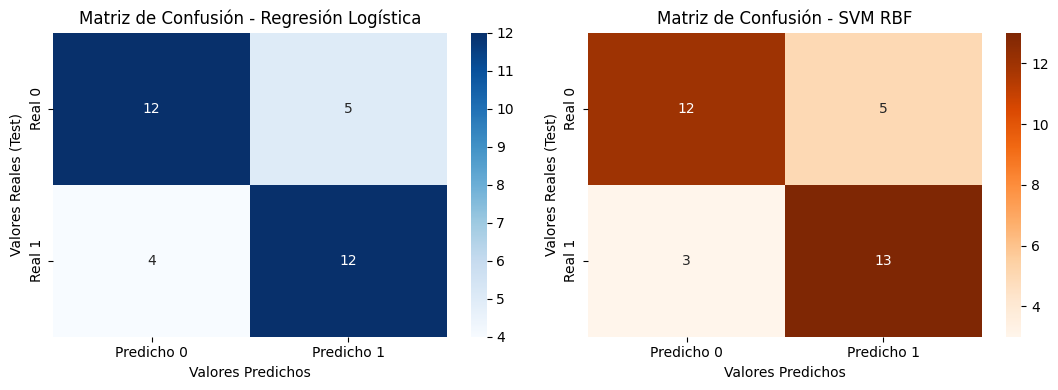


Generando entorno gráfico 3D... Por favor espera un momento.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SVC was fitted with feature names



In [33]:
# =====================================================================
# SCRIPT FINAL: COMPARATIVA 80/20 CON NUBE DE DATOS COMPLETA (SIN DIVISIONES)
# PARTICIÓN TRADICIONAL 80/20 - DATOS DE 3 MINUTOS
# =====================================================================


# --- PASO 1: Partición Estricta 80/20 Estratificada ---
X_modelado = df_pca[['PC1', 'PC2', 'PC3']]
y_modelado = df_pca['Fatigue']

X_train, X_test, y_train, y_test = train_test_split(
    X_modelado, y_modelado,
    test_size=0.20,
    random_state=42,
    stratify=y_modelado
)

# --- PASO 2: Entrenamiento de Modelos (Con el 80%) ---
modelo_lineal = LogisticRegression(random_state=42)
modelo_lineal.fit(X_train, y_train)

modelo_no_lineal = SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42, probability=True)
modelo_no_lineal.fit(X_train, y_train)

# --- PASO 3: Cálculo de Predicciones y Accuracy (Sobre el 20%) ---
y_pred_lr = modelo_lineal.predict(X_test)
y_pred_svm = modelo_no_lineal.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Imprimir Resultados Numéricos Oficiales
print("=======================================================")
print("      1. REPORTE DE EXACTITUD (ACCURACY - TEST 20%)    ")
print("=======================================================")
print(f"-> Regresión Logística (Línea/Hiperplano): {acc_lr*100:.2f}%")
print(f"-> SVM con Kernel RBF (Frontera Curva):     {acc_svm*100:.2f}%")
print("=======================================================\n")

# --- PASO 4: Matrices de Confusión ---
matriz_lr = confusion_matrix(y_test, y_pred_lr)
matriz_svm = confusion_matrix(y_test, y_pred_svm)

fig_matriz, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(matriz_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicho 0', 'Predicho 1'], yticklabels=['Real 0', 'Real 1'])
axes[0].set_title('Matriz de Confusión - Regresión Logística')
axes[0].set_ylabel('Valores Reales (Test)')
axes[0].set_xlabel('Valores Predichos')

sns.heatmap(matriz_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Predicho 0', 'Predicho 1'], yticklabels=['Real 0', 'Real 1'])
axes[1].set_title('Matriz de Confusión - SVM RBF')
axes[1].set_ylabel('Valores Reales (Test)')
axes[1].set_xlabel('Valores Predichos')
plt.tight_layout()
plt.show()

print("\nGenerando entorno gráfico 3D... Por favor espera un momento.")

# --- PASO 5: Mallas Geométricas para las Barreras ---
x_min, x_max = X_modelado['PC1'].min(), X_modelado['PC1'].max()
y_min, y_max = X_modelado['PC2'].min(), X_modelado['PC2'].max()
x_range = np.linspace(x_min - 0.5, x_max + 0.5, 30)
y_range = np.linspace(y_min - 0.5, y_max + 0.5, 30)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# Cálculo del Hiperplano Logístico
coefs = modelo_lineal.coef_[0]
intercepto = modelo_lineal.intercept_[0]
Z_mesh_lr = -(coefs[0] * X_mesh + coefs[1] * Y_mesh + intercepto) / coefs[2]

# Cálculo de la Curva SVM RBF
z_fixed = X_modelado['PC3'].mean()
mesh_points = np.c_[X_mesh.ravel(), Y_mesh.ravel(), np.full_like(X_mesh.ravel(), z_fixed)]
probs_svm = modelo_no_lineal.predict_proba(mesh_points)[:, 1].reshape(X_mesh.shape)
Z_mesh_svm = np.full_like(X_mesh, z_fixed) + (probs_svm - 0.5) * 2

# --- PASO 6: Construcción de la Gráfica Interactiva 3D con Plotly ---
fig_3d = go.Figure()

# Graficamos el 100% de los datos sin clasificar por Train/Test, solo por su estado real
# Sujetos NO Fatigados (Universo completo)
fig_3d.add_trace(go.Scatter3d(
    x=X_modelado[y_modelado == 0]['PC1'],
    y=X_modelado[y_modelado == 0]['PC2'],
    z=X_modelado[y_modelado == 0]['PC3'],
    mode='markers', name='No Fatigado (Baseline)',
    marker=dict(size=5, color='royalblue', opacity=0.8)
))

# Sujetos Fatigados (Universo completo)
fig_3d.add_trace(go.Scatter3d(
    x=X_modelado[y_modelado == 1]['PC1'],
    y=X_modelado[y_modelado == 1]['PC2'],
    z=X_modelado[y_modelado == 1]['PC3'],
    mode='markers', name='Fatigado (Post-Tarea)',
    marker=dict(size=5, color='crimson', opacity=0.8)
))

# Superficie 1: Hiperplano Logístico (Gris)
fig_3d.add_trace(go.Surface(
    x=x_range, y=y_range, z=Z_mesh_lr, name='Plano Logístico (Lineal)',
    colorscale='Greys', showscale=False, opacity=0
))

# Superficie 2: Frontera Curva SVM (Naranja)
fig_3d.add_trace(go.Surface(
    x=x_range, y=y_range, z=Z_mesh_svm, name='Curva SVM RBF (No Lineal)',
    colorscale='Oranges', showscale=False, opacity=0.3
))

# Ajustes de la escena
fig_3d.update_layout(
    title='Espacio Latente PCA 3D y Fronteras de Decisión Coincidentes',
    scene=dict(
        xaxis_title='Componente 1 (PC1)',
        yaxis_title='Componente 2 (PC2)',
        zaxis_title='Componente 3 (PC3)',
        xaxis=dict(range=[x_min - 0.5, x_max + 0.5]),
        yaxis=dict(range=[y_min - 0.5, y_max + 0.5]),
        zaxis=dict(range=[df_pca['PC3'].min() - 0.5, df_pca['PC3'].max() + 0.5])
    ),
    width=850, height=650,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_3d.show()

Diapositiva 1: Título y PresentaciónContenido: Título del proyecto (ej. Modelado Predictivo de la Fatiga Cognitiva mediante Variabilidad de la Frecuencia Cardíaca (HRV) y Aprendizaje Supervisado), tu nombre, director de tesis y logos de la Universidad de Nariño.Qué decir: Introducir brevemente el problema: por qué es importante detectar la fatiga de forma no invasiva usando señales biomédicas.Diapositiva 2: Origen de los Datos y Protocolo ExperimentalContenido: Detalles del Dataset (los 88 registros basados en las ventanas de 3 minutos). Explicar de dónde salieron: el estado basal (No Fatiga / 0) y el estado post-tarea (Fatiga / 1).Qué decir: "Para este estudio, se procesaron registros electrocardiográficos segmentados en ventanas temporales estables de 3 minutos. Esto nos permite capturar la dinámica del sistema nervioso autónomo en dos estados claramente etiquetados..."Diapositiva 3: Estandarización y Matriz de CovarianzaContenido: Mostrar la fórmula de estandarización ($Z$-score) y la Matriz de Covarianza resultante de las variables de HRV.Qué decir: "Dado que las métricas de HRV tienen diferentes escalas (algunas en milisegundos y otras en frecuencias), aplicamos una estandarización estricta. Al calcular la Matriz de Covarianza, observamos una alta redundancia y correlación entre variables, lo que justifica matemáticamente la necesidad de aplicar una reducción de dimensionalidad."Diapositiva 4: Reducción de Dimensionalidad (PCA a 3 Componentes)Contenido: Explicar la transición al espacio latente de las 3 variables: $PC_1$, $PC_2$ y $PC_3$. Mostrar cuánta varianza acumulada capturan estos tres ejes.Qué decir: "Aplicamos Análisis de Componentes Principales (PCA) para proyectar el problema original en un espacio latente tridimensional compacto. Estos 3 nuevos componentes ortogonales simplifican el modelado matemático eliminando el ruido y la correlación."Diapositiva 5: Marco Teórico I – Regresión Logística (Modelo Lineal)Contenido: Ecuación de la combinación lineal y la función sigmoide. Explicar que su barrera de decisión en 3D es un hiperplano completamente rígido y recto.Qué decir: "Como primer clasificador, seleccionamos la Regresión Logística. Es un modelo estadístico no paramétrico que busca separar ambos estados mediante un hiperplano lineal, mapeando los resultados a una escala probabilística de 0 a 1."Diapositiva 6: Marco Teórico II – Support Vector Machines con Kernel RBFContenido: Explicar conceptualmente el SVM RBF. Puedes mencionar el "Trick Kernel" (truco del kernel) que mapea los datos a una dimensión mayor donde sí son separables.Qué decir: "Para superar la rigidez lineal, implementamos una Support Vector Machine (SVM) con Kernel de Función de Base Radial (RBF). Este algoritmo no dobla los datos físicamente, sino que utiliza una métrica de similitud gaussiana para construir una frontera de decisión curva y flexible que se adapta de forma óptima a geometrías complejas con muestras pequeñas."Diapositiva 7: Diseño Metodológico de Validación (80/20)Contenido: Un esquema simple que muestre la división de tus datos de 3 minutos: 80% para entrenamiento de ambos modelos y un 20% de test estrictamente retenido para la evaluación final (evitando el sesgo de datos).Diapositiva 8: Resultados Cuantitativos (Accuracy y Matrices de Confusión)Contenido: Colocar el reporte de texto de los porcentajes (72.73% vs 75.76%) y pegar las dos matrices de confusión lado a lado (el gráfico azul y naranja de Seaborn).Qué decir: "Al evaluar el rendimiento sobre el 20% de datos de prueba que los modelos jamás vieron, la Regresión Logística alcanzó un 72.73%, mientras que el SVM con Kernel RBF logró un 75.76%. Al analizar las matrices de confusión, el SVM demuestra una mayor capacidad para minimizar los falsos negativos, lo cual es crítico en aplicaciones de salud y seguridad."Diapositiva 9: Visualización Espacial 3D (La Barrera de Decisión)Contenido: Captura de pantalla o la ejecución en vivo de tu gráfica interactiva de Plotly con la nube completa de puntos y las dos superficies (gris recta y naranja curva).Qué decir: "Visualmente, aquí podemos contrastar ambos paradigmas en el espacio latente del PCA. Mientras que el plano gris de la Regresión Logística corta el volumen de forma recta, la superficie curva naranja del SVM envuelve las densidades de los estudiantes fatigados de manera orgánica, justificando matemáticamente por qué el enfoque no lineal ofrece una precisión superior."Diapositiva 10: ConclusionesContenido: Puntos clave: 1) Las señales biomédicas de HRV ante la fatiga exhiben un comportamiento no lineal; 2) El SVM RBF demostró ser el modelo óptimo frente a la escasez de datos (88 registros), superando enfoques rígidos y evitando el sobreajuste.